# Customer Churn Prediction.

## Model Evaluation.

En esta fase del proyecto se realiza una evaluación detallada de los modelos entrenados previamente con el objetivo de analizar su capacidad predictiva y comprender mejor su comportamiento.

Se evaluarán métricas de clasificación, matrices de confusión, curvas ROC e importancia de variables para identificar el modelo más adecuado para el problema de predicción de churn.

## Importamos librerías.

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)

In [2]:
os.makedirs(
    r"..\images",
    exist_ok=True
)

# Carga de datasets procesados.

In [3]:
X_train = pd.read_csv(
    r"..\Data\Processed\X_train.csv"
)

X_test = pd.read_csv(
    r"..\Data\Processed\X_test.csv"
)

y_train = pd.read_csv(
    r"..\Data\Processed\y_train.csv"
).squeeze()

y_test = pd.read_csv(
    r"..\Data\Processed\y_test.csv"
).squeeze()

# Reentrenamiento de modelos.

Para realizar la evaluación detallada se entrenan nuevamente los modelos seleccionados.

## Regresión logística.

In [4]:
log_model = LogisticRegression(
    random_state=72
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

y_prob_log = log_model.predict_proba(X_test)[:,1]

## Árbol de decisión.

In [5]:
tree_model = DecisionTreeClassifier(
    random_state=72,
    max_depth=5
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

y_prob_tree = tree_model.predict_proba(X_test)[:,1]

## Random Forest.

In [6]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=8
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

## XGBoost.

In [7]:
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

# Matrices de confusión.

La matriz de confusión permite analizar el comportamiento de los modelos identificando aciertos y errores de clasificación.

## Matriz de confusión: Regresión logística.

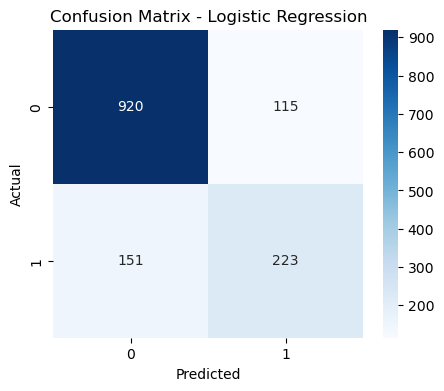

In [8]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig(
    r"..\images\confusion_matrix_logistic.png",
    bbox_inches='tight'
)

plt.show()

La matriz de confusión del modelo __Regresión Logística__ refleja un desempeño sólido en la predicción del churn de clientes, mostrando una buena capacidad tanto para identificar clientes estables como para detectar posibles abandonos.

El modelo clasifica correctamente `920` clientes que no abandonan el servicio (`True Negatives`), lo que indica una adecuada capacidad para reconocer clientes con permanencia en la compañía. Asimismo, identifica correctamente `223` clientes que efectivamente presentan churn (`True Positives`).

No obstante, se observan `151` falsos negativos, es decir, clientes que realmente abandonan la compañía pero que el modelo clasifica incorrectamente como clientes que permanecerán. Desde una perspectiva de negocio, este tipo de error resulta especialmente importante, ya que implica posibles pérdidas de clientes sin oportunidad de aplicar acciones preventivas de retención.

Por otro lado, el número de falsos positivos (`115`) se mantiene relativamente contenido, indicando que el modelo no genera un exceso de alertas erróneas sobre clientes que finalmente permanecerán en la empresa. Esto permite evitar costos innecesarios asociados a campañas de fidelización.

En conjunto, la Regresión Logística presenta un comportamiento equilibrado y una capacidad predictiva adecuada para el problema de *churn prediction*, mostrando un buen equilibrio entre detección de clientes con riesgo de abandono y control de falsas alarmas.

## Matriz de confusión: Decision Tree.

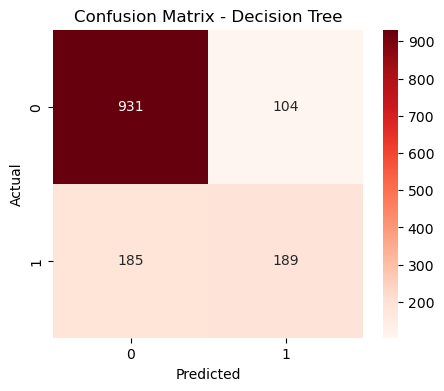

In [9]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

La matriz de confusión del modelo __Árbol de Decisión__ muestra un desempeño aceptable en la predicción del churn de clientes, aunque con ciertas limitaciones en la detección de clientes con riesgo de abandono.

El modelo clasifica correctamente `911` clientes que no abandonan el servicio (`True Negatives`), lo que evidencia una capacidad razonable para identificar clientes estables dentro de la compañía. Asimismo, identifica correctamente `189` clientes que efectivamente presentan churn (`True Positives`).

Sin embargo, se observan `185` falsos negativos, es decir, clientes que realmente abandonan la compañía pero que el modelo clasifica incorrectamente como clientes que permanecerán. Este tipo de error resulta especialmente relevante desde una perspectiva de negocio, ya que implica posibles pérdidas de clientes sin posibilidad de aplicar estrategias preventivas de retención.

Por otro lado, el número de falsos positivos (`104`) se mantiene relativamente moderado, indicando que el modelo no genera un exceso de alertas incorrectas sobre clientes que finalmente no abandonarían el servicio. Esto ayuda a evitar costos innecesarios asociados a acciones de fidelización.

En conjunto, el modelo de Árbol de Decisión presenta un comportamiento estable y fácil de interpretar, aunque muestra un menor nivel de precisión en la detección de churn en comparación con modelos más avanzados como Random Forest o XGBoost. Aun así, constituye una alternativa útil cuando se prioriza la interpretabilidad del modelo.

## Matriz de confusión: Random Forest.

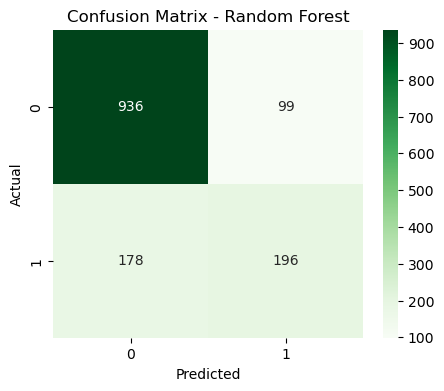

In [10]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

La matriz de confusión del modelo __Random Forest__ refleja un desempeño competitivo en la predicción del churn de clientes, mostrando una buena capacidad para identificar correctamente a los clientes que permanecen en la compañía.

El modelo clasifica correctamente `936` clientes que no abandonan el servicio (`True Negatives`), lo que evidencia una elevada precisión al reconocer clientes estables. Además, identifica correctamente `196` clientes que efectivamente presentan churn (`True Positives`).

No obstante, se observan `178` falsos negativos, es decir, clientes que realmente abandonan la compañía pero que el modelo no logra detectar adecuadamente. Este tipo de error continúa siendo relevante desde el punto de vista del negocio, ya que implica posibles pérdidas de clientes sin que puedan aplicarse estrategias preventivas de retención.

Por otro lado, el número de falsos positivos (`99`) resulta relativamente bajo, indicando que el modelo evita generar demasiadas alertas incorrectas sobre clientes que finalmente permanecerán en la empresa. Esto contribuye a reducir costos asociados a campañas de retención innecesarias.

En términos generales, el modelo Random Forest muestra un comportamiento robusto y estable, destacándose especialmente por su capacidad para reducir los falsos positivos. Sin embargo, todavía presenta margen de mejora en la detección de clientes con churn, debido al número de falsos negativos observados.

## Matriz de confusión: XGBoost.

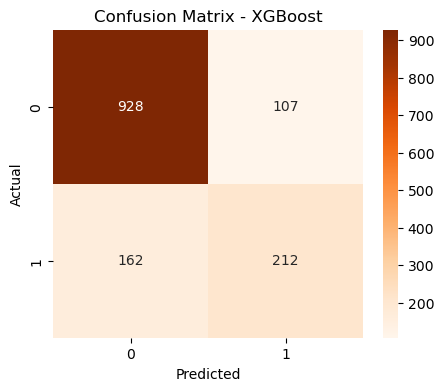

In [11]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

La matriz de confusión del modelo __XGBoost (XGB)__ refleja un desempeño sólido y equilibrado en la predicción del churn de clientes, mostrando una buena capacidad tanto para identificar clientes estables como para detectar posibles abandonos.

El modelo clasifica correctamente `928` clientes que no abandonan el servicio (`True Negatives`), evidenciando una adecuada capacidad para reconocer clientes con permanencia en la compañía. Asimismo, identifica correctamente `212` clientes que efectivamente presentan churn (`True Positives`).

Sin embargo, se observan `162` falsos negativos, es decir, clientes que realmente abandonan la compañía pero que el modelo no consigue detectar correctamente. Desde el punto de vista del negocio, este tipo de error sigue siendo relevante, ya que implica posibles pérdidas de clientes sin la posibilidad de implementar estrategias preventivas de retención.

Por otro lado, el número de falsos positivos (`107`) se mantiene en niveles relativamente moderados, indicando que el modelo evita generar un exceso de alertas incorrectas sobre clientes que finalmente no abandonarían el servicio. Esto contribuye a optimizar recursos y minimizar costos asociados a campañas de retención innecesarias.

En términos generales, el modelo XGBoost presenta un comportamiento robusto y una capacidad predictiva competitiva para el problema de *churn prediction*, ofreciendo un equilibrio adecuado entre la detección de clientes con riesgo de abandono y el control de falsas alarmas.

# Classification Report.

Analizamos las métricas de clasificación de forma más detallada para cada clase.

## Classification Report: Regresión logística.

In [12]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1035
           1       0.66      0.60      0.63       374

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



La regresión logística presenta el rendimiento más equilibrado entre todos los modelos evaluados, destacando especialmente en métricas como `Recall` y `F1 Score` para la detección de clientes con churn.

El modelo logra identificar correctamente una proporción relevante de clientes con riesgo de abandono manteniendo, al mismo tiempo, una buena precisión global.

Estos resultados refuerzan la capacidad de la regresión logística como modelo interpretable, robusto y competitivo para el problema de predicción de churn.

## Classification Report: Decision Tree.

In [13]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



El árbol de decisión obtiene el rendimiento más limitado entre los modelos analizados, mostrando una menor capacidad para detectar correctamente clientes con churn.

Se observa una reducción en métricas como `Recall` y `F1 Score`, lo que indica una mayor dificultad para identificar clientes con riesgo de abandono.

Aunque el modelo aporta interpretabilidad y simplicidad estructural, su capacidad predictiva resulta inferior a la observada en modelos ensemble y en la regresión logística.

## Classification Report: Random Forest.

In [14]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



Random Forest mejora parcialmente el rendimiento respecto al árbol de decisión simple, ofreciendo una mayor estabilidad y robustez predictiva.

El modelo mantiene una buena capacidad de discriminación entre clientes con y sin churn, gracias a la combinación de múltiples árboles de decisión.

No obstante, todavía existe margen de mejora en la detección de clientes con riesgo de abandono, especialmente en términos de `Recall`.

## Classification Report: XGBoost.

In [15]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



XGBoost presenta un rendimiento sólido y competitivo, mostrando un equilibrio adecuado entre `Precision`, `Recall` y `F1 Score`.

El modelo mejora la capacidad de detección de churn respecto al árbol de decisión y mantiene un comportamiento muy competitivo frente a Random Forest y la regresión logística.

Estos resultados confirman la eficacia de los modelos de boosting en problemas de clasificación tabular como la predicción de abandono de clientes.

# Curvas ROC.

Las curvas ROC permiten comparar visualmente la capacidad de discriminación de los distintos modelos evaluando la relación entre verdaderos positivos y falsos positivos.

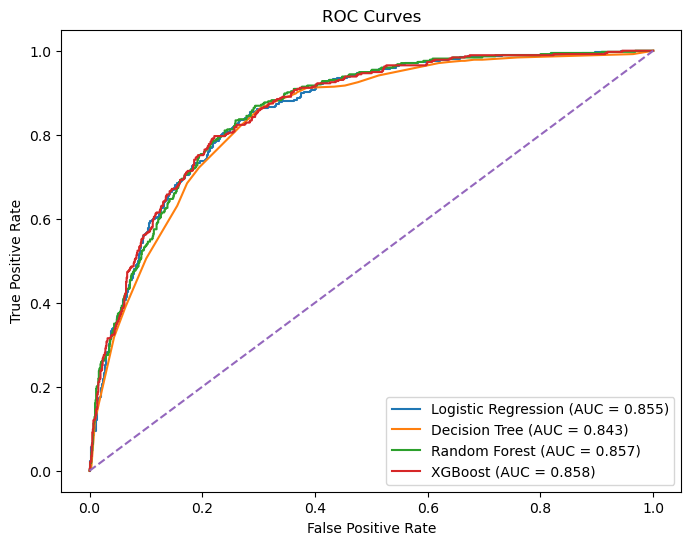

In [16]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)

fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.3f})'
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_prob_tree):.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})'
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curves')

plt.legend()

plt.savefig(
    r"..\images\roc_curve.png",
    bbox_inches='tight'
)

plt.show()

Los valores de `ROC AUC` obtenidos muestran que todos los modelos presentan una buena capacidad de discriminación entre clientes que abandonan el servicio y aquellos que permanecen activos.

Random Forest y XGBoost alcanzan los valores más elevados (`0.857` y `0.858` respectivamente), reflejando un rendimiento ligeramente superior en la separación entre ambas clases.

La regresión logística mantiene también un resultado muy competitivo (`0.855`), confirmando que un modelo más interpretable puede ofrecer un rendimiento comparable al de modelos más complejos.

Por su parte, el árbol de decisión simple obtiene el valor más bajo (`0.843`), aunque sigue mostrando una capacidad predictiva razonablemente sólida para el problema de churn prediction.

# Importancia de variables.

Se analiza la importancia de las variables en los distintos modelos para identificar los factores más relevantes asociados al abandono de clientes.

En los modelos basados en árboles se utiliza la importancia de variables (`feature_importances_`), mientras que en la regresión logística se analizan los coeficientes del modelo.

## Importancia de variables: Regresión logística.

In [17]:
log_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_model.coef_[0]
})

log_importance['Absolute_Coefficient'] = abs(
    log_importance['Coefficient']
)

log_importance = log_importance.sort_values(
    by='Absolute_Coefficient',
    ascending=False
).head(10)

log_importance = log_importance.reset_index(drop=True)

log_importance

,Feature,Coefficient,Absolute_Coefficient
0,Contract_Two year,-1.425924,1.425924
1,tenure,-1.401662,1.401662
2,InternetService_Fiber optic,1.045774,1.045774
3,TotalCharges,0.680646,0.680646
4,Contract_One year,-0.637687,0.637687
5,PhoneService_Yes,-0.545661,0.545661
6,PaymentMethod_Electronic check,0.363941,0.363941
7,OnlineSecurity_Yes,-0.329352,0.329352
8,StreamingMovies_Yes,0.319743,0.319743
9,PaperlessBilling_Yes,0.318186,0.318186


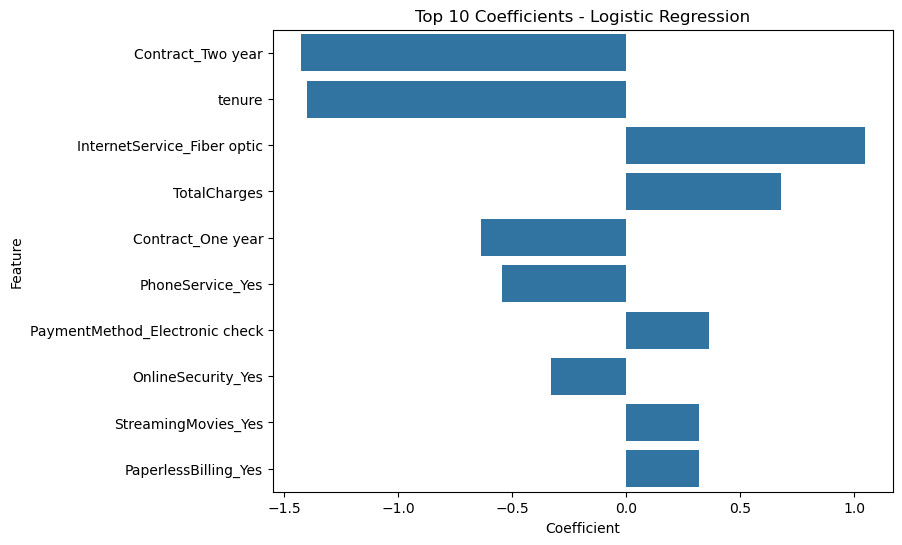

In [18]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=log_importance,
    x='Coefficient',
    y='Feature'
)

plt.title('Top 10 Coefficients - Logistic Regression')

plt.savefig(
    r"..\images\feature_importance_logistic.png",
    bbox_inches='tight'
)

plt.show()

La __regresión logística__ identifica como factores más relevantes para reducir el churn la antigüedad del cliente (`tenure`) y los contratos de larga duración (`Contract_Two year` y `Contract_One year`), cuyos coeficientes negativos indican una menor probabilidad de cancelación.

Por el contrario, variables como `InternetService_Fiber optic`, `PaymentMethod_Electronic check` y `PaperlessBilling_Yes` presentan coeficientes positivos asociados a una mayor probabilidad de abandono.

Estos resultados muestran una interpretación clara del comportamiento de los clientes y permiten identificar factores clave relacionados con fidelización y riesgo de churn.

## Importancia de variables: Decision Tree.

In [19]:
tree_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': tree_model.feature_importances_
})

tree_importance = tree_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

tree_importance = tree_importance.reset_index(drop=True)

tree_importance

,Feature,Importance
0,tenure,0.388536
1,InternetService_Fiber optic,0.350899
2,Contract_Two year,0.066560
3,TotalCharges,0.042057
4,MonthlyCharges,0.039303
5,Contract_One year,0.036202
6,InternetService_No,0.031948
7,PaymentMethod_Electronic check,0.016761
8,PhoneService_Yes,0.008823
9,OnlineSecurity_No internet service,0.007745


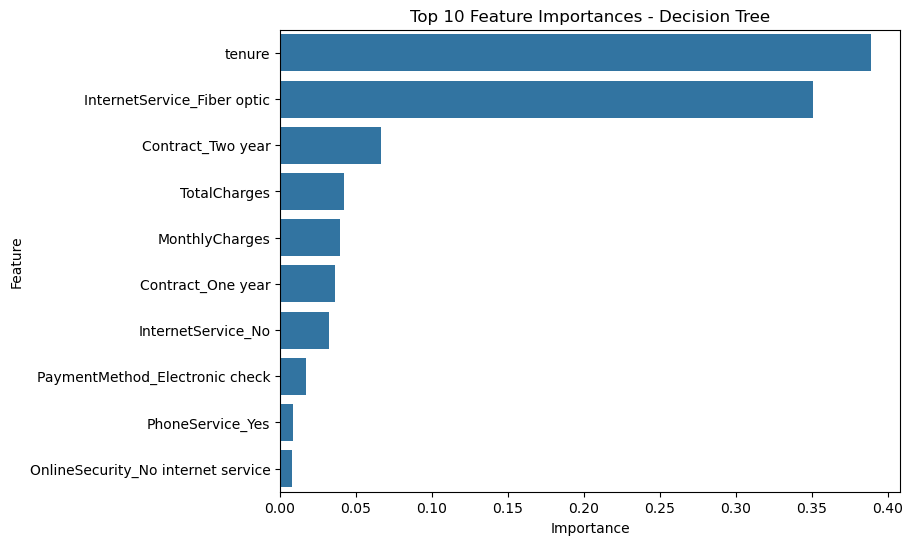

In [20]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=tree_importance,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importances - Decision Tree')

plt.savefig(
    r"..\images\feature_importance_tree.png",
    bbox_inches='tight'
)

plt.show()

__Decision tree__ identifica `tenure` e `InternetService_Fiber optic` como las variables más influyentes en la predicción de churn.

También destacan variables relacionadas con tipo de contrato, cargos mensuales y facturación acumulada, lo que sugiere que tanto la permanencia del cliente como el tipo de servicio contratado son factores clave en el riesgo de cancelación.

Aunque el modelo presenta un rendimiento inferior al de otros algoritmos más complejos, ofrece una interpretación intuitiva de las decisiones de clasificación.

## Importancia de variables: Random Forest.

In [21]:
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

rf_importance = rf_importance.reset_index(drop=True)

rf_importance

,Feature,Importance
0,tenure,0.194304
1,TotalCharges,0.155308
2,MonthlyCharges,0.093850
3,InternetService_Fiber optic,0.089226
4,Contract_Two year,0.077444
5,PaymentMethod_Electronic check,0.064799
6,OnlineSecurity_Yes,0.037103
7,Contract_One year,0.033824
8,TechSupport_Yes,0.025702
9,TechSupport_No internet service,0.017962


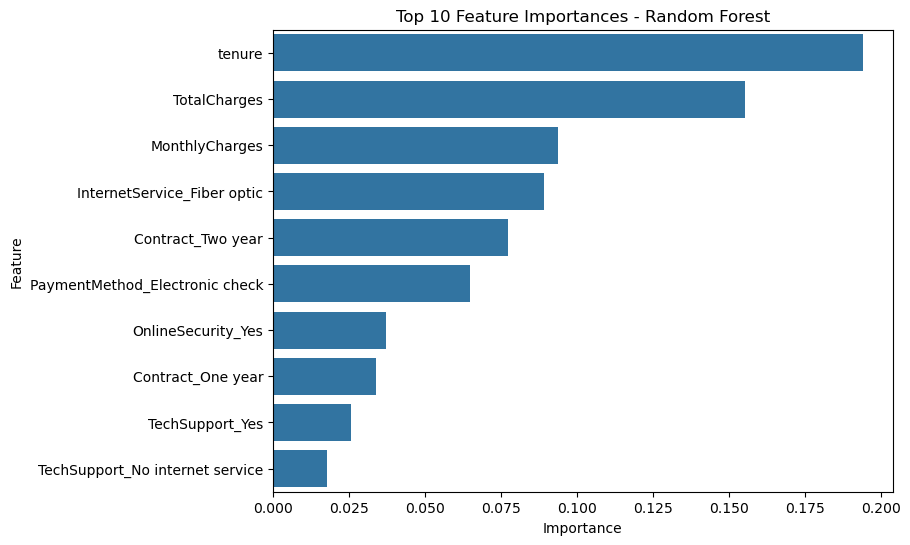

In [22]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=rf_importance,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importances - Random Forest')

plt.savefig(
    r"..\images\feature_importance_rf.png",
    bbox_inches='tight'
)

plt.show()

__Random Forest__ muestra un patrón consistente con los análisis anteriores, destacando variables como `tenure`, `TotalCharges`, `MonthlyCharges` y `InternetService_Fiber optic` entre los factores más relevantes.

La importancia asignada a variables relacionadas con antigüedad y facturación refuerza la hipótesis de que la estabilidad del cliente y el coste del servicio influyen significativamente en la probabilidad de churn.

La combinación de múltiples árboles permite además capturar relaciones más complejas y mejorar la robustez del modelo.

## Importancia de variables: XGBoost.

In [23]:
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

xgb_importance = xgb_importance.reset_index(drop=True)

xgb_importance

,Feature,Importance
0,InternetService_Fiber optic,0.286393
1,Contract_Two year,0.239681
2,Contract_One year,0.139205
3,InternetService_No,0.066878
4,StreamingMovies_Yes,0.041541
5,tenure,0.038425
6,PaymentMethod_Electronic check,0.020288
7,OnlineSecurity_Yes,0.019336
8,PaperlessBilling_Yes,0.019303
9,TechSupport_Yes,0.016341


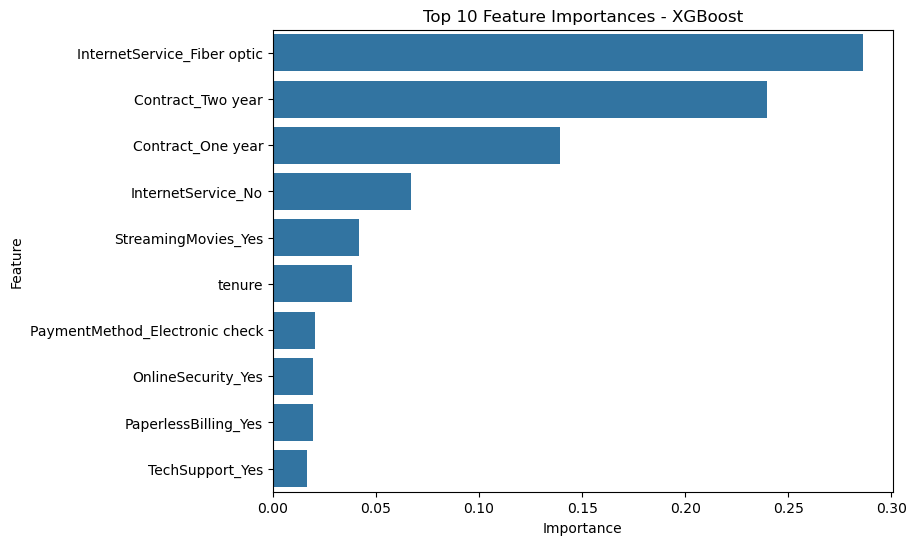

In [24]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=xgb_importance,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importances - XGBoost')

plt.savefig(
    r"..\images\feature_importance_xgb.png",
    bbox_inches='tight'
)

plt.show()

__XGBoost__ identifica principalmente variables relacionadas con tipo de contrato e Internet como factores determinantes en la predicción de churn.

En particular, `InternetService_Fiber optic` y los contratos de larga duración aparecen como variables de gran relevancia, junto con factores asociados a facturación electrónica y servicios adicionales.

Estos resultados confirman la capacidad de XGBoost para detectar patrones complejos y relaciones no lineales entre variables, ofreciendo un rendimiento predictivo muy competitivo.

# Insights generales sobre variables relevantes.

Los distintos modelos analizados muestran patrones consistentes respecto a las variables más influyentes en la predicción de churn.

Entre los factores más relevantes destacan:

- `tenure` (antigüedad del cliente)
- tipo de contrato
- `MonthlyCharges`
- `TotalCharges`
- tipo de servicio de Internet
- método de pago

En general, los clientes con menor antigüedad, contratos mensuales y cargos mensuales elevados presentan una mayor probabilidad de abandonar el servicio.

Por el contrario, los contratos de larga duración y una mayor permanencia en la compañía aparecen asociados a una mayor fidelización y menor riesgo de churn.

Estos resultados son coherentes con los patrones identificados previamente durante el análisis exploratorio de datos.

# Selección final del modelo.

Aunque los modelos ensemble (`Random Forest` y `XGBoost`) presentan una ligera ventaja en capacidad predictiva y valores de `ROC AUC`, la regresión logística mantiene un rendimiento muy competitivo junto con una elevada interpretabilidad.

La regresión logística destaca especialmente por su equilibrio entre `Precision`, `Recall` y `F1 Score`, además de permitir interpretar fácilmente el impacto de cada variable sobre la probabilidad de churn.

Por otro lado, Random Forest y XGBoost permiten capturar relaciones más complejas y no lineales entre variables, ofreciendo una mayor robustez general.

La elección final del modelo dependerá del equilibrio deseado entre interpretabilidad, capacidad predictiva y facilidad de implementación en un entorno de negocio.

# Conclusiones de negocio.

El análisis realizado permite identificar varios factores clave asociados al abandono de clientes en la empresa de telecomunicaciones.

Los clientes con menor antigüedad presentan una probabilidad significativamente mayor de cancelar el servicio, especialmente durante los primeros meses de contratación.

Asimismo, los contratos mensuales muestran tasas de churn más elevadas en comparación con contratos de uno o dos años, lo que sugiere una menor fidelización.

También se observa que los clientes con mayores cargos mensuales y determinados servicios de Internet presentan una mayor tendencia al abandono.

Estos hallazgos pueden utilizarse para desarrollar estrategias de retención más efectivas, enfocadas especialmente en clientes nuevos, clientes con contratos mensuales y usuarios con mayor riesgo de cancelación.

# Conclusiones finales del proyecto.

En este proyecto se desarrolló un pipeline completo de machine learning para la predicción de churn en una empresa de telecomunicaciones.

A lo largo del análisis se realizaron tareas de comprensión y limpieza de datos, análisis exploratorio, preprocesamiento, entrenamiento de modelos y evaluación comparativa.

Los resultados obtenidos muestran que modelos como `Random Forest` y `XGBoost` ofrecen una elevada capacidad predictiva, mientras que la regresión logística aporta una solución interpretable y muy competitiva.

Además de la construcción de modelos predictivos, el proyecto permitió identificar factores de negocio relevantes asociados al abandono de clientes, aportando información útil para el diseño de estrategias de fidelización y retención.

Este proyecto demuestra cómo las técnicas de análisis de datos y machine learning pueden utilizarse para apoyar la toma de decisiones estratégicas en entornos empresariales reales.